In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../Dataset/HR_Strategic.csv")

print(df.shape)

df.head()

(1470, 40)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeGroup,EmployeeExperienceIndex,RiskScore,RiskCategory,SalaryBand
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,6,4,0,5,36-45,2.00,2,Low Risk,High
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,3,10,7,1,7,46-55,3.00,3,Medium Risk,High
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,0,0,0,0,36-45,3.00,5,High Risk,Low
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,8,7,3,0,26-35,3.25,5,High Risk,Low
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,2,2,2,2,26-35,2.50,5,High Risk,Medium


In [16]:
df_ml = df.copy()

categorical_cols = df_ml.select_dtypes(
    include='object'
).columns

le = LabelEncoder()

for col in categorical_cols:
    df_ml[col] = le.fit_transform(
        df_ml[col]
    )

print("Encoding Complete")

Encoding Complete


In [17]:
X = df_ml.drop(
    columns=['Attrition']
)

y = df_ml['Attrition']

print(X.shape)
print(y.shape)

(1470, 39)
(1470,)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1176, 39)
(294, 39)


In [19]:
model = LogisticRegression(
    max_iter=5000
)

model.fit(
    X_train,
    y_train
)

print(
    "Model Training Complete"
)

Model Training Complete


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
y_pred = model.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(
        accuracy*100,
        2
    ),
    "%"
)

Accuracy: 88.44 %


In [21]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.90      0.97      0.94       255
           1       0.63      0.31      0.41        39

    accuracy                           0.88       294
   macro avg       0.77      0.64      0.67       294
weighted avg       0.87      0.88      0.87       294



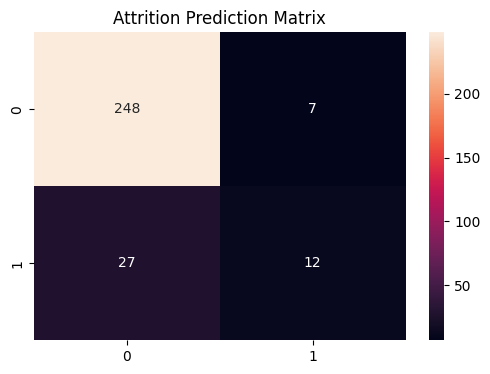

In [22]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    'Attrition Prediction Matrix'
)

plt.show()

In [23]:
importance = pd.DataFrame({

    'Feature':
    X.columns,

    'Coefficient':
    model.coef_[0]

})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

importance.head(15)

,Feature,Coefficient
21,OverTime,0.747277
16,MaritalStatus,0.577478
36,RiskScore,0.493117
3,Department,0.440475
10,Gender,0.349978
19,NumCompaniesWorked,0.205843
34,AgeGroup,0.193489
1,BusinessTravel,0.181098
15,JobSatisfaction,0.142510
30,YearsAtCompany,0.117670


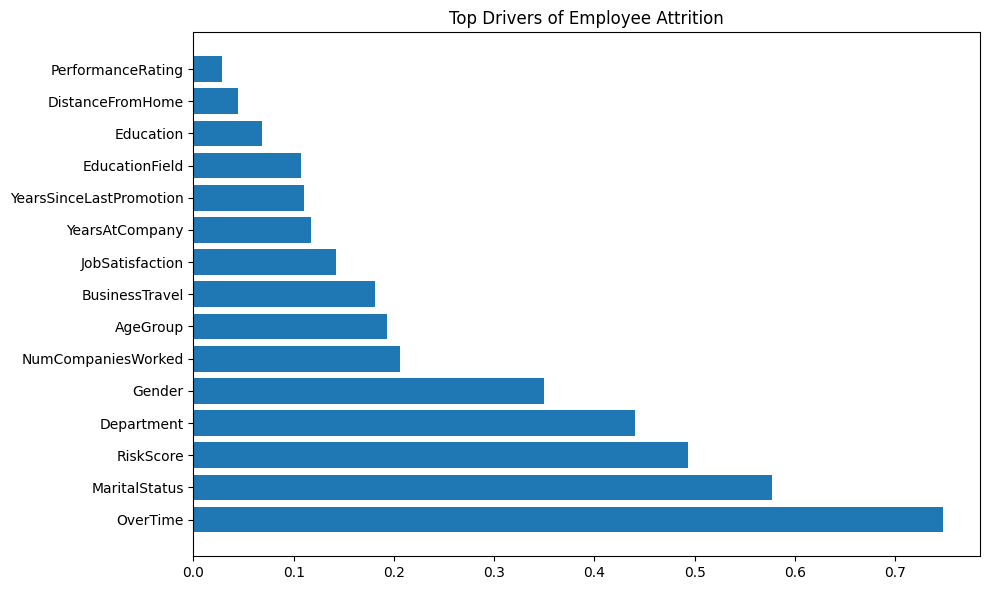

In [24]:
top_features = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Coefficient']
)

plt.title(
    'Top Drivers of Employee Attrition'
)

plt.tight_layout()

plt.show()

In [25]:
df['AttritionProbability'] = model.predict_proba(
    X
)[:,1]

In [26]:
df['PredictedAttrition'] = np.where(
    df['AttritionProbability'] > 0.5,
    'Likely To Leave',
    'Likely To Stay'
)

In [27]:
df[[
    'AttritionProbability',
    'PredictedAttrition'
]].head()

,AttritionProbability,PredictedAttrition
0,0.694277,Likely To Leave
1,0.017910,Likely To Stay
2,0.730757,Likely To Leave
3,0.158243,Likely To Stay
4,0.543753,Likely To Leave


In [28]:
df.to_csv(
    "../Dataset/HR_Final_Analytics.csv",
    index=False
)

print(
    "Final Analytics Dataset Saved"
)

Final Analytics Dataset Saved
